In [19]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
print(PROJECT_ROOT)

/Users/florianb/Downloads/ai-customer-insights-engine


In [20]:
import pandas as pd

from src.data import preprocess_dataset

from config import config

In [21]:
import importlib

importlib.reload(config)
importlib.reload(preprocess_dataset)

<module 'src.data.preprocess_dataset' from '/Users/florianb/Downloads/ai-customer-insights-engine/src/data/preprocess_dataset.py'>

In [53]:
print(f"RAW_DATA_PATH = {config.RAW_DATA_PATH}")
print(f"PROCESSED_DATA_PATH = {config.PROCESSED_DATA_PATH}")


RAW_DATA_PATH = /Users/florianb/Downloads/ai-customer-insights-engine/data/raw/scraped_reviews_final.csv
PROCESSED_DATA_PATH = /Users/florianb/Downloads/ai-customer-insights-engine/data/processed/processed_reviews.parquet


In [23]:
df_raw = pd.read_csv(config.RAW_DATA_PATH)

In [ ]:
df_raw.head()

In [25]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 55198 entries, 0 to 55197
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   pseudo            55196 non-null  str  
 1   publication_date  55198 non-null  str  
 2   rating            55198 non-null  int64
 3   title             55198 non-null  str  
 4   review            48394 non-null  str  
 5   experience_date   55198 non-null  str  
 6   total_reviews     55198 non-null  int64
 7   bank              55198 non-null  str  
dtypes: int64(2), str(6)
memory usage: 16.9 MB


### Validation de `remove_invalid_rows()`

In [26]:
df_after_remove_invalid_rows = preprocess_dataset.remove_invalid_rows(df_raw)

In [27]:
df_after_remove_invalid_rows.info()

<class 'pandas.DataFrame'>
RangeIndex: 48385 entries, 0 to 48384
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   pseudo            48385 non-null  str  
 1   publication_date  48385 non-null  str  
 2   rating            48385 non-null  int64
 3   title             48385 non-null  str  
 4   review            48385 non-null  str  
 5   experience_date   48385 non-null  str  
 6   total_reviews     48385 non-null  int64
 7   bank              48385 non-null  str  
dtypes: int64(2), str(6)
memory usage: 16.0 MB


### Validation de `remove_unnecessary_columns()`

In [28]:
df_after_remove_unnecessary_columns = preprocess_dataset.remove_unnecessary_columns(df_raw)

In [29]:
df_after_remove_unnecessary_columns.info()

<class 'pandas.DataFrame'>
RangeIndex: 55198 entries, 0 to 55197
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   publication_date  55198 non-null  str  
 1   rating            55198 non-null  int64
 2   title             55198 non-null  str  
 3   review            48394 non-null  str  
 4   experience_date   55198 non-null  str  
 5   bank              55198 non-null  str  
dtypes: int64(1), str(5)
memory usage: 15.5 MB


### Validation de `process_datetime_features()`

In [30]:
df_after_process_datetime_features = preprocess_dataset.process_datetime_features(df_raw)

In [31]:
df_after_process_datetime_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 55198 entries, 0 to 55197
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype                       
---  ------            --------------  -----                       
 0   pseudo            55196 non-null  str                         
 1   publication_date  55198 non-null  datetime64[us, Europe/Paris]
 2   rating            55198 non-null  int64                       
 3   title             55198 non-null  str                         
 4   review            48394 non-null  str                         
 5   experience_date   55198 non-null  datetime64[us]              
 6   total_reviews     55198 non-null  int64                       
 7   bank              55198 non-null  str                         
 8   year              55198 non-null  int32                       
 9   month             55198 non-null  int32                       
 10  year_month        55198 non-null  str                         
dtypes: datetime64

### Validation de `clean_text()`

In [32]:
tests = [
    "<p>Super produit.<br>Je recommande !</p>",

    "J'ai vu sur le site https://exemple.com qu'il y avait",
    "J'ai vu sur le site https://www.exemple.com qu'il y avait",
    "J'ai vu sur le site http://exemple.com qu'il y avait",
    "J'ai vu sur le site http://www.exemple.com qu'il y avait",
    "J'ai vu sur le site www.exemple.com qu'il y avait",
    "Lien : https://exemple.com/page/test",
    "Lien : https://www.exemple.com?id=123",
    "Lien : http://exemple.com/page/test",
    "Lien : http://www.exemple.com?id=123",
    "Plusieurs liens : https://site1.com et http://site2.com",

    "Contactez-moi à client.test@gmail.com",
    "Contactez-moi à clienttest@gmail.fr",

    "Appelez-moi au 0612345678 pour plus d'informations",
    "Appelez-moi au 06 12 34 56 78 pour plus d'informations",
    "Appelez-moi au 06.12.34.56.78 pour plus d'informations",
    "Appelez-moi au 06-12-34-56-78 pour plus d'informations",
    "Appelez-moi au +33612345678 pour plus d'informations",
    "Appelez-moi au +33(0)6 12 34 56 78 pour plus d'informations",

    "Génial!!!C'est fiable??Ça marche...vraiment.",

    "  Bonjour\n\n   tout le monde,\t Ceci est  un test.  \n\n  ",
]

for text in tests:
    print("AVANT :", text)
    print("APRÈS :", preprocess_dataset.clean_text(text))
    print("-" * 50)

AVANT : <p>Super produit.<br>Je recommande !</p>
APRÈS : Super produit. Je recommande !
--------------------------------------------------
AVANT : J'ai vu sur le site https://exemple.com qu'il y avait
APRÈS : J'ai vu sur le site qu'il y avait
--------------------------------------------------
AVANT : J'ai vu sur le site https://www.exemple.com qu'il y avait
APRÈS : J'ai vu sur le site qu'il y avait
--------------------------------------------------
AVANT : J'ai vu sur le site http://exemple.com qu'il y avait
APRÈS : J'ai vu sur le site qu'il y avait
--------------------------------------------------
AVANT : J'ai vu sur le site http://www.exemple.com qu'il y avait
APRÈS : J'ai vu sur le site qu'il y avait
--------------------------------------------------
AVANT : J'ai vu sur le site www.exemple.com qu'il y avait
APRÈS : J'ai vu sur le site qu'il y avait
--------------------------------------------------
AVANT : Lien : https://exemple.com/page/test
APRÈS : Lien :
------------------------

In [ ]:
# À GÉRER
# "mon identifiant", "mon id", "mon mot de passe", "mon password", "mon adresse [postale]", "mon numéro [de compte]", "mon tél", "mon mail", etc...

### Validation du pipeline `main()` via le notebook

In [33]:
preprocess_dataset.main(
    input_path=config.RAW_DATA_PATH, 
    output_path=PROJECT_ROOT / "data/processed/processed_reviews_test_notebook.parquet"
)

In [34]:
df_processed = pd.read_parquet(PROJECT_ROOT / "data/processed/processed_reviews_test_notebook.parquet")

In [ ]:
df_processed.head()

,publication_date,rating,title,review,experience_date,bank,review_id,year,month,year_month
0,2025-03-07 14:48:17+01:00,5,Banque pas chère,Banque pas chère,2025-03-07,boursobank,0,2025,3,2025-03
1,2025-03-07 14:45:35+01:00,5,Modif plafond retrait,"Gestion aisée de mon compte. Pas de frais, auc...",2025-03-07,boursobank,1,2025,3,2025-03
2,2025-03-07 14:35:24+01:00,5,Facilité,Rajouter un bénéficiaire et tout s'est bien dé...,2025-03-07,boursobank,2,2025,3,2025-03
3,2025-03-07 14:20:03+01:00,4,Trop d'étape de sécurité,J'ai mis 4 étoiles parce que je trouve qu'il a...,2025-03-01,boursobank,3,2025,3,2025-03
4,2025-03-07 13:28:32+01:00,4,Je recommande cette carte pour les…,Je recommande cette carte pour les voyageurs e...,2025-03-06,boursobank,4,2025,3,2025-03


In [37]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 48389 entries, 0 to 48388
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype                       
---  ------            --------------  -----                       
 0   publication_date  48389 non-null  datetime64[us, Europe/Paris]
 1   rating            48389 non-null  int64                       
 2   title             48389 non-null  str                         
 3   review            48389 non-null  str                         
 4   experience_date   48389 non-null  datetime64[us]              
 5   bank              48389 non-null  str                         
 6   review_id         48389 non-null  int64                       
 7   year              48389 non-null  int32                       
 8   month             48389 non-null  int32                       
 9   year_month        48389 non-null  str                         
dtypes: datetime64[us, Europe/Paris](1), datetime64[us](1), int32(2), int64(2), str(4)

In [38]:
print("Nbre de balises HTML :", df_processed["review"].str.contains(r"<.*?>", regex=True).sum())
print("Nbre d'URLs :", df_processed["review"].str.contains(r"https?://\S+|www\.\S+", regex=True).sum())
print("Nbre d'emails :", df_processed["review"].str.contains(r"\S*@\S+", regex=True).sum())
print("Nbre de numéros de téléphone :", df_processed["review"].str.contains(r"\+?\d[\d\s\-.]{8,}\d", regex=True).sum())
print("Nbre d'absences d'espace après les '.', '!' et '?' :", df_processed["review"].str.contains(r"[.!?]+(?![.!?])(?=\S)", regex=True).sum())
print("Nbre d'espaces en trop et de caractères d'espacement :", df_processed["review"].str.contains(r"^\s|\s$|\s{2,}", regex=True).sum())

Nbre de balises HTML : 0
Nbre d'URLs : 0
Nbre d'emails : 0
Nbre de numéros de téléphone : 8
Nbre d'absences d'espace après les '.', '!' et '?' : 0
Nbre d'espaces en trop et de caractères d'espacement : 0


In [46]:
phone_mask = df_processed["review"].str.contains(r"\+?\d[\d\s\-.]{8,}\d", regex=True)

df_processed.loc[phone_mask, "review"].str.findall(r"\+?\d[\d\s\-.]{8,}\d")

17328                [17. 12. 24]
23832    [91-13. 136, 91-13. 136]
24956                [18. 12. 24]
25091                [12. 12. 24]
26257                [02. 08. 24]
29154               [28. 8. 2023]
30070               [6. 02. 2020]
48284                [16. 10. 19]
Name: review, dtype: object

In [51]:
df_processed["review"].str.len().describe().round(2)

count    48389.00
mean       190.02
std        291.04
min         10.00
25%         39.00
50%         87.00
75%        219.00
max       4855.00
Name: review, dtype: float64

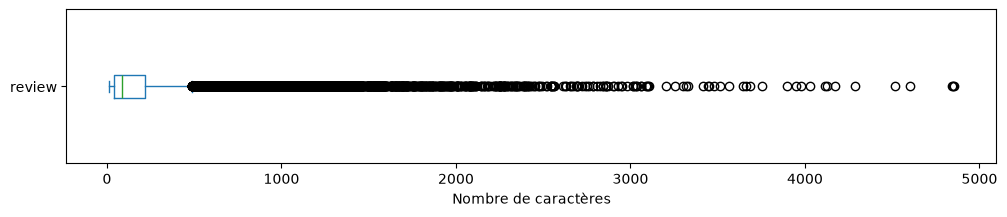

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))
df_processed["review"].str.len().plot.box(vert=False)

plt.xlabel("Nombre de caractères")
plt.show()

### Validation du pipeline `main()` via le terminal

In [54]:
df_processed_script = pd.read_parquet(config.PROCESSED_DATA_PATH)

In [55]:
df_processed_script.head()

,publication_date,rating,title,review,experience_date,bank,review_id,year,month,year_month
0,2025-03-07 14:48:17+01:00,5,Banque pas chère,Banque pas chère,2025-03-07,boursobank,0,2025,3,2025-03
1,2025-03-07 14:45:35+01:00,5,Modif plafond retrait,"Gestion aisée de mon compte. Pas de frais, aucun problème.",2025-03-07,boursobank,1,2025,3,2025-03
2,2025-03-07 14:35:24+01:00,5,Facilité,Rajouter un bénéficiaire et tout s'est bien déroulé.,2025-03-07,boursobank,2,2025,3,2025-03
3,2025-03-07 14:20:03+01:00,4,Trop d'étape de sécurité,J'ai mis 4 étoiles parce que je trouve qu'il a beaucoup etapes de sécurité C'est compréhensif mais ça mis trop de temps et trop d'étape pour faire un truc simple C'était juste mes débuts peut-être après je changerai d'avis 😉,2025-03-01,boursobank,3,2025,3,2025-03
4,2025-03-07 13:28:32+01:00,4,Je recommande cette carte pour les…,Je recommande cette carte pour les voyageurs et pour les commandes sur internet,2025-03-06,boursobank,4,2025,3,2025-03


In [56]:
df_processed_script.info()

<class 'pandas.DataFrame'>
RangeIndex: 48389 entries, 0 to 48388
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype                       
---  ------            --------------  -----                       
 0   publication_date  48389 non-null  datetime64[us, Europe/Paris]
 1   rating            48389 non-null  int64                       
 2   title             48389 non-null  str                         
 3   review            48389 non-null  str                         
 4   experience_date   48389 non-null  datetime64[us]              
 5   bank              48389 non-null  str                         
 6   review_id         48389 non-null  int64                       
 7   year              48389 non-null  int32                       
 8   month             48389 non-null  int32                       
 9   year_month        48389 non-null  str                         
dtypes: datetime64[us, Europe/Paris](1), datetime64[us](1), int32(2), int64(2), str(4)

In [57]:
df_processed_script.equals(df_processed)

True